# 05 — Household consumption-savings solver via Endogenous Grid Method

**Ports**: `Code/MATLAB/Steady_State_Ayagari/solve_EGM_EL_open_tg.m`.

**Inputs**: `../output/params.npz` (asset grid, calibrated SS prices, productivity Markov chain).

**Outputs (saved to `../output/egm_ss.npz`)**:
- `cpol` `(nA, ns)` — consumption of home good on the coarse asset grid.
- `dec`  `(nA, ns)` — implied savings policy on the coarse grid.
- `c_fine`   `(nA_fine, ns)` — consumption on the fine grid.
- `dec_fine` `(nA_fine, ns)` — savings policy on the fine grid.
- `a_today`  `(nA, ns)` — endogenous-grid asset values used during the last iteration.
- `c_s`      `(nA, ns)` — EGM consumption-from-FOC at the savings grid.

**What's solved here** (paper §3, household block, recursive form):
$$V(a, s) = \max_{c, a'} u(c) - g(\bar\ell)
+ \beta\,\mathbb E[V(a', s') \mid s]$$
subject to
$$P_t c = (1+i^a) a + W \bar\ell s + d - a'\quad\text{and}\quad a' \geq \underline a.$$

With CRRA $u$, a CES home/foreign aggregator (parameter $\theta$, share $\omega$), and steady-state terms of trade $T_{ss}=1$, the FOC pinning down current consumption $c$ given a saving choice $a'$ is
$$c^{-\gamma} = \beta(1+r)\,\mathbb E[c'^{-\gamma}\mid s]$$
and EGM proceeds by inverting it on the savings grid `Agrid` to obtain consumption $c_s$, then computing the implied today's-asset $a_{today}$ from the budget identity, and finally interpolating $c_s$ as a function of $a_{today}$ onto `Agrid` to update the policy.

## Imports + load parameters

In [1]:
from pathlib import Path
import time

import numpy as np
from scipy.interpolate import PchipInterpolator
import matplotlib.pyplot as plt

OUTPUT_DIR = Path('..') / 'output'
p = np.load(OUTPUT_DIR / 'params.npz')

# Asset grids
Agrid = p['params__Agrid']
Agrid_fine = p['params__Agrid_fine']
nA = int(p['params__nA'])
nA_fine = int(p['params__nA_fine'])
Index_b_min = int(p['params__Index_b_min'])
bmin = float(p['params__bmin'])

# Markov chain
ex = p['params__ex']
piex = p['params__piex']
ns = int(p['params__ns'])

# Steady-state prices
r_ss = float(p['params__r_ss'])
w_ss = float(p['params__w_ss'])
pi_ss = float(p['params__pi_ss'])
T_ss = float(p['params__T_ss'])

# Structural parameters
alpha = float(p['params__alpha'])
gamma = float(p['params__gamma'])
theta = float(p['params__theta'])
omega = float(p['params__omega'])
l_bar = float(p['params__l_bar'])

# Initial guess for beta from Main.m line 203 (Ind_sol=1 path)
beta_init = 0.9832

print(f'nA = {nA}, nA_fine = {nA_fine}, ns = {ns}')
print(f'r_ss = {r_ss:.6f}, w_ss = {w_ss:.6f}, pi_ss = {pi_ss:.6f}')
print(f'beta_init (warm start) = {beta_init}')

nA = 193, nA_fine = 769, ns = 7
r_ss = 0.010610, w_ss = 1.846716, pi_ss = 0.306255
beta_init (warm start) = 0.9832


## EGM solver

Faithful port of `solve_EGM_EL_open_tg.m` (29-line MATLAB file). The key data shapes:
- `c0`, `c_new`, `c_s`, `a_today`, `Emup`, `Emup1` are all `(nA, ns)` matrices.
- `sav_grid[i, j] = Agrid[i]` (broadcast across labour productivity).
- `exLw[i, j] = ex[j]` (broadcast across asset).

**Note on the consumption multiplier.** With $\theta = 1$ and $T_{ss} = 1$, the term `(1 + T_ss^{(theta-1)} * omega/(1-omega))` simplifies to $1/(1-\omega)$. We keep the general MATLAB form for fidelity.

In [2]:
def cons_multiplier(T, theta, omega):
    """`(1 + T^{theta-1} * omega/(1-omega))` from Main.m / solve_EGM_EL_open_tg.m.

    Maps home-good consumption c_h to total spending on the CES bundle
    (home + foreign goods).
    """
    return 1.0 + T ** (theta - 1.0) * omega / (1.0 - omega)


def solve_egm(
    r,
    beta,
    *,
    Agrid,
    Agrid_fine,
    ex,
    piex,
    Index_b_min,
    bmin,
    r_ss,
    w_ss,
    pi_ss,
    T_ss,
    omega,
    theta,
    gamma,
    l_bar,
    c0=None,
    tol=1e-12,
    max_iter=5000,
    verbose=False,
):
    """Solve the household problem at given (r, beta) by iterating the EGM operator.

    Returns dict with cpol, dec, c_fine, dec_fine, a_today, c_s, n_iter, max_diff_final.
    """
    nA = Agrid.size
    nA_fine = Agrid_fine.size
    ns = ex.size

    sav_grid = np.tile(Agrid[:, None], (1, ns))   # (nA, ns)
    exLw = np.tile(ex[None, :], (nA, 1))          # (nA, ns)
    mult = cons_multiplier(T_ss, theta, omega)    # scalar

    # Initial guess (from calibrate_beta_open_tg.m lines 28-34): r * Agrid (interest income),
    # not (1+r) * Agrid (full asset value). Empirically a good warm start.
    if c0 is None:
        c0 = (
            (1.0 / mult)
            * (w_ss * exLw * l_bar + r * sav_grid + pi_ss)
        )
        c0 = np.maximum(c0, 1e-5)

    # Constrained consumption: budget identity with a' = bmin
    c_constrained = np.maximum(
        (1.0 / mult)
        * (w_ss * exLw * l_bar + (1.0 + r_ss) * sav_grid + pi_ss - bmin),
        1e-5,
    )

    c_new = np.empty_like(c0)
    a_today = np.empty_like(c0)
    c_s = np.empty_like(c0)

    for m in range(1, max_iter + 1):
        # Step 1: marginal utility next period (one for each (a', s') pair)
        Emup1 = c0 ** (-gamma)

        # Step 2: expected next-period MU given current state s
        # piex is row-stochastic: piex[s, s'] = P(s' | s).  MATLAB writes Emup1*piex'
        # which in numpy is Emup1 @ piex.T.
        Emup = beta * (1.0 + r_ss) * (Emup1 @ piex.T)

        # Step 3: invert FOC to get c_s on the savings grid
        c_s_iter = Emup ** (-1.0 / gamma)

        # Step 4: implied today's assets
        a_today_iter = (
            c_s_iter * mult + sav_grid - w_ss * exLw * l_bar - pi_ss
        ) / (1.0 + r)

        # Step 5: interpolate c_s as a function of a_today onto Agrid for each s
        for j in range(ns):
            xj = a_today_iter[:, j]
            cj = c_s_iter[:, j]
            threshold = a_today_iter[Index_b_min, j]
            unconstrained_mask = Agrid > threshold
            interp = PchipInterpolator(xj, cj, extrapolate=True)
            c_unconstrained = interp(Agrid)
            c_new[:, j] = np.where(
                unconstrained_mask, c_unconstrained, c_constrained[:, j]
            )
        c_new = np.maximum(c_new, 1e-5)

        max_diff = np.max(np.abs(c_new - c0))
        if max_diff < tol:
            if verbose:
                print(f'  EGM converged after {m} iterations (max_diff = {max_diff:.3e})')
            a_today[...] = a_today_iter
            c_s[...] = c_s_iter
            c0 = c_new.copy()
            break

        update = 0.5 if max_diff < 1e-4 else 0.9
        c0 = update * c_new + (1.0 - update) * c0
        a_today[...] = a_today_iter
        c_s[...] = c_s_iter
    else:
        if verbose:
            print(f'  EGM did NOT converge after {max_iter} iterations (max_diff = {max_diff:.3e})')

    cpol = c0
    # Decision rule for assets on the coarse grid
    dec = (1.0 + r) * Agrid[:, None] + exLw * w_ss * l_bar - cpol * mult + pi_ss

    # Fine-grid policies
    c_fine = np.zeros((nA_fine, ns))
    dec_fine = np.zeros((nA_fine, ns))
    for j in range(ns):
        xj = a_today[:, j]
        cj = c_s[:, j]
        threshold = a_today[Index_b_min, j]
        unconstrained_mask_fine = Agrid_fine > threshold
        interp_unconstrained = PchipInterpolator(xj, cj, extrapolate=True)
        interp_constrained = PchipInterpolator(Agrid, c_constrained[:, j], extrapolate=True)
        c_fine_j = np.where(
            unconstrained_mask_fine,
            interp_unconstrained(Agrid_fine),
            interp_constrained(Agrid_fine),
        )
        c_fine[:, j] = c_fine_j
        dec_unconstrained = (
            (1.0 + r) * Agrid_fine + ex[j] * w_ss * l_bar - c_fine_j * mult + pi_ss
        )
        dec_fine[:, j] = np.where(
            unconstrained_mask_fine, dec_unconstrained, bmin
        )

    return dict(
        cpol=cpol,
        dec=dec,
        c_fine=c_fine,
        dec_fine=dec_fine,
        a_today=a_today,
        c_s=c_s,
        n_iter=m,
        max_diff_final=max_diff,
    )

## Solve at the calibrated `(r_ss, beta_init)` and time it

In [3]:
tic = time.time()
out = solve_egm(
    r=r_ss,
    beta=beta_init,
    Agrid=Agrid,
    Agrid_fine=Agrid_fine,
    ex=ex,
    piex=piex,
    Index_b_min=Index_b_min,
    bmin=bmin,
    r_ss=r_ss,
    w_ss=w_ss,
    pi_ss=pi_ss,
    T_ss=T_ss,
    omega=omega,
    theta=theta,
    gamma=gamma,
    l_bar=l_bar,
    tol=1e-12,
    max_iter=5000,
    verbose=True,
)
elapsed = time.time() - tic
print(f'\nElapsed: {elapsed:.2f} s')
print(f'Iterations: {out["n_iter"]}')
print(f'Final max diff: {out["max_diff_final"]:.3e}')

  EGM converged after 1998 iterations (max_diff = 9.663e-13)

Elapsed: 0.85 s
Iterations: 1998
Final max diff: 9.663e-13


## Sanity checks

1. Consumption policy should be increasing in assets (more wealth → more consumption).
2. Consumption should be increasing in productivity at every asset level.
3. Savings $a'$ should be increasing in assets and weakly above `bmin`.

In [4]:
cpol = out['cpol']
dec = out['dec']
c_fine = out['c_fine']
dec_fine = out['dec_fine']

print('--- Coarse grid checks ---')
print(f'cpol shape : {cpol.shape}, range = [{cpol.min():.4f}, {cpol.max():.4f}]')
print(f'dec shape  : {dec.shape}, range = [{dec.min():.4f}, {dec.max():.4f}]')
for j in range(ns):
    not_monotone = np.any(np.diff(cpol[:, j]) < -1e-8)
    print(f'  productivity index {j} (e={ex[j]:.4f}): cpol monotone in a? {not not_monotone}')

# At the lowest productivity, lowest assets should bind to bmin
j_low = 0
n_at_bmin = int(np.sum(np.isclose(dec[:, j_low], bmin, atol=1e-6)))
print(f'  At lowest productivity, # of states at the borrowing constraint: {n_at_bmin} / {nA}')

print('\n--- Fine grid checks ---')
print(f'c_fine shape : {c_fine.shape}, range = [{c_fine.min():.4f}, {c_fine.max():.4f}]')
print(f'dec_fine shape : {dec_fine.shape}, range = [{dec_fine.min():.4f}, {dec_fine.max():.4f}]')
assert np.all(c_fine > 0), 'c_fine should be strictly positive'
assert np.all(dec_fine >= bmin - 1e-6), 'savings should be above the borrowing constraint'

--- Coarse grid checks ---
cpol shape : (193, 7), range = [0.0000, 305.9878]
dec shape  : (193, 7), range = [-239.5303, 29500.9836]
  productivity index 0 (e=0.0904): cpol monotone in a? True
  productivity index 1 (e=0.1795): cpol monotone in a? True
  productivity index 2 (e=0.3563): cpol monotone in a? True
  productivity index 3 (e=0.7074): cpol monotone in a? True
  productivity index 4 (e=1.4046): cpol monotone in a? True
  productivity index 5 (e=2.7888): cpol monotone in a? True
  productivity index 6 (e=5.5371): cpol monotone in a? True
  At lowest productivity, # of states at the borrowing constraint: 6 / 193

--- Fine grid checks ---
c_fine shape : (769, 7), range = [0.0000, 305.9878]
dec_fine shape : (769, 7), range = [-0.0000, 29500.9836]


## Visualise consumption and savings policies

Plotted on the fine grid, against assets, for each labour productivity state. The borrowing constraint shows up as a flat "floor" in the savings policy at the lowest assets.

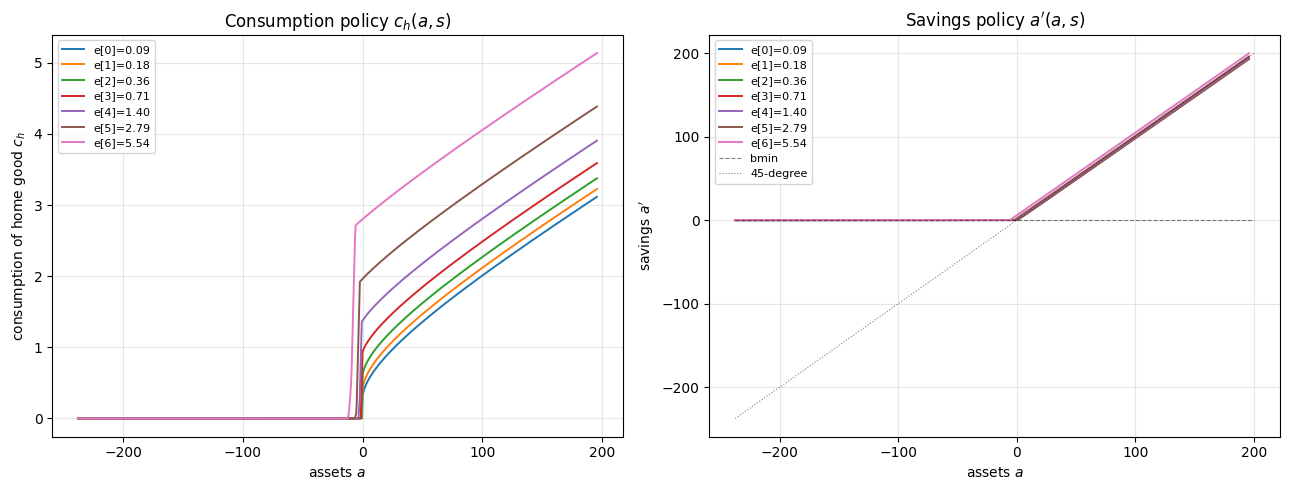

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Restrict to a meaningful asset range for visualisation; the full grid extends
# to ~30,000 (huge) but realised assets in the stationary distribution will be
# concentrated near 0 to a few hundred.
vis_max = 200.0
vis_mask = Agrid_fine <= vis_max
x_vis = Agrid_fine[vis_mask]

for j in range(ns):
    label = f'e[{j}]={ex[j]:.2f}'
    axes[0].plot(x_vis, c_fine[vis_mask, j], lw=1.4, label=label)
    axes[1].plot(x_vis, dec_fine[vis_mask, j], lw=1.4, label=label)

axes[0].set_xlabel('assets $a$')
axes[0].set_ylabel('consumption of home good $c_h$')
axes[0].set_title('Consumption policy $c_h(a, s)$')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8, loc='best')

axes[1].plot([Agrid_fine.min(), vis_max], [bmin, bmin], 'k--', lw=0.8, alpha=0.5, label='bmin')
axes[1].plot([Agrid_fine.min(), vis_max], [Agrid_fine.min(), vis_max], 'k:', lw=0.8, alpha=0.5, label='45-degree')
axes[1].set_xlabel('assets $a$')
axes[1].set_ylabel("savings $a'$")
axes[1].set_title("Savings policy $a'(a, s)$")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

## Save outputs

Notebook 06 will load `cpol`, `c_fine`, and `dec_fine` to build the stationary distribution.

In [6]:
out_path = OUTPUT_DIR / 'egm_ss.npz'
np.savez(
    out_path,
    cpol=cpol,
    dec=dec,
    c_fine=c_fine,
    dec_fine=dec_fine,
    a_today=out['a_today'],
    c_s=out['c_s'],
    n_iter=out['n_iter'],
    max_diff_final=out['max_diff_final'],
    r=r_ss,
    beta=beta_init,
)
print(f'Saved: {out_path}')

Saved: /Users/siyingli/github/de-Ferra2020-kz/Code/Python/output/egm_ss.npz
